## P25_37a
- Parameter and landscape sweeps
- Will need to re-explore a bit with these new models

In [1]:
import json, math, re
from pathlib import Path
from tqdm import tqdm
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision.models.resnet import ResNet, BasicBlock

RUNS = Path("/home/stephen/Stephencwelch Dropbox/welch_labs/resnet/hackin/aug_17_run")                       # <-- output dir of train_depth_sweep.py
DATA = Path("/home/stephen/imagenet")     # <-- edit
device = "cuda" if torch.cuda.is_available() else "cpu"

MODEL_DEPTHS = {"plain8": 8, "plain14": 14, "plain20": 20, "plain26": 26,
                "plain34": 34, "plain56": 56, "plain74": 74, "resnet74": 74}
MODELS = [m for m in MODEL_DEPTHS if (RUNS / m).exists()]

def color_of(name):
    """Plain nets: dark->light with depth. ResNet: red."""
    if name == "resnet74":
        return "crimson"
    depths = sorted(d for m, d in MODEL_DEPTHS.items() if m != "resnet74")
    return plt.cm.viridis(depths.index(MODEL_DEPTHS[name]) / (len(depths) - 1))

print(torch.__version__, device, "| runs found:", MODELS)

2.12.1+cu130 cuda | runs found: ['plain8', 'plain14', 'plain20', 'plain26', 'plain34', 'plain56', 'plain74', 'resnet74']


In [2]:
# --- model definitions (mirrors train_depth_sweep.py) ---
class PlainBasicBlock(BasicBlock):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.downsample = None

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.relu(self.bn2(self.conv2(out)))
        return out

LAYER_CFG = {8: [1,1,1,1], 14: [2,1,1,2], 20: [2,2,3,2], 26: [3,3,3,3],
             34: [4,4,4,4], 56: [3,4,17,3], 74: [3,4,26,3]}

def make_net(depth_target, use_skip, num_classes=1000):
    block = BasicBlock if use_skip else PlainBasicBlock
    model = ResNet(block, LAYER_CFG[depth_target], num_classes=num_classes)
    if depth_target == 8:
        model.layer4 = nn.Identity()
        model.fc = nn.Linear(256, num_classes)
    return model

def blocks_of(model):
    return [b for s in (model.layer1, model.layer2, model.layer3, model.layer4)
            if isinstance(s, nn.Sequential) for b in s]

In [3]:
def list_ckpts(name):
    return sorted(int(re.search(r"(\d+)", p.stem).group(1))
                  for p in (RUNS / name).glob("ckpt_step*.pt"))

def load_model(name, step=None):
    d = RUNS / name
    path = d / "final.pt" if step is None else d / f"ckpt_step{step:06d}.pt"
    model = make_net(MODEL_DEPTHS[name], use_skip=name.startswith("resnet"))
    model.load_state_dict(torch.load(path, map_location=device))
    return model.to(device).eval()

print("plain74 checkpoints:", list_ckpts("plain74")[:5], "...",
      list_ckpts("plain74")[-2:])

plain74 checkpoints: [1000, 2000, 3000, 4000, 5000] ... [99000, 100000]


## Load Model

In [4]:
model=load_model('plain8')
# model=load_model('plain14')

In [5]:
# --- validation data (same transforms as training script) ---
import torchvision.datasets as dsets, torchvision.transforms as T

MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
val_ds = dsets.ImageFolder(DATA / "ILSVRC/Data/CLS-LOC/val",
    T.Compose([T.Resize(256), T.CenterCrop(224), T.ToTensor(),
               T.Normalize(MEAN, STD)]))
val_loader = torch.utils.data.DataLoader(val_ds, 64, shuffle=True,
    num_workers=4, pin_memory=True)

# wnid -> human-readable name (Kaggle CLS-LOC ships this mapping)
wnid_words = {}
mapping = DATA / "LOC_synset_mapping.txt"
if mapping.exists():
    for line in open(mapping):
        wnid, words = line.strip().split(" ", 1)
        wnid_words[wnid] = words.split(",")[0]

def class_name(idx):
    if 0 <= idx < len(val_ds.classes):
        wnid = val_ds.classes[idx]
        return wnid_words.get(wnid, wnid)
    return f"cls{idx}"

def denorm(x):  # CHW tensor -> HWC numpy in [0,1] for imshow
    img = x.cpu() * torch.tensor(STD).view(3,1,1) + torch.tensor(MEAN).view(3,1,1)
    return img.clamp(0, 1).permute(1, 2, 0).numpy()

print(len(val_ds), "val images,", len(val_ds.classes), "classes")

50000 val images, 1000 classes


In [6]:
# @torch.no_grad()
# def validate(model, loader):
#     model.eval()
#     top1 = top5 = total = 0
#     for x, y in tqdm(loader, desc="val"):
#         x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
#         with torch.amp.autocast(device, enabled=(device == "cuda")):
#             logits = model(x)
#         _, pred5 = logits.topk(5, dim=1)
#         correct = pred5.eq(y.unsqueeze(1))
#         top1 += correct[:, 0].sum().item()
#         top5 += correct.any(dim=1).sum().item()
#         total += y.numel()
#     return top1 / total, top5 / total

# acc1, acc5 = validate(model, val_loader)
# print(f"top-1: {acc1:.4f}   top-5: {acc5:.4f}")

## High Gradient Parameter Sweeps

In [7]:
# ---- gradient-ranked sweeps over many random val images (all fp32) ----
LAYER_IDXS = [0, 1, 2, 3, -4, -3, -2, -1]  # layers to iterate through
N_IMAGES   = 256                 # random val images for the big run
TOP_N      = 20                  # top-N weights by |grad| per model per layer
SPAN       = 3.0
N_POINTS   = 128
IMG_SEED   = 25                  # seeds which images get chosen
PLOT_DELTA = False

rng = np.random.default_rng(IMG_SEED)
img_idxs = rng.choice(len(val_ds), size=N_IMAGES, replace=False)
print(f"images: {list(img_idxs)}")

def load_image(idx):
    x, y = val_ds[idx]
    return x.unsqueeze(0).to(device), torch.tensor([y], device=device)

crit = nn.CrossEntropyLoss()

@torch.no_grad()
def batch_loss_fp32(model, x, y):
    return crit(model(x), y).item()

@torch.no_grad()
def correct_ans_conf(model, x, y):
    return torch.nn.Softmax()(model(x))[0, y.item()].item()

def layer_grad(model, layer, x, y):
    """|dL/dw| for one layer at the trained point, single backward, fp32."""
    model.zero_grad(set_to_none=True)
    loss = crit(model(x), y)
    loss.backward()
    g = layer.weight.grad.detach().flatten().clone()
    model.zero_grad(set_to_none=True)
    return g

def weighted_layers(model):
    """(name, module) for convs + fc in forward order, excluding 1x1 shortcuts."""
    return [(n, m) for n, m in model.named_modules()
            if isinstance(m, (nn.Conv2d, nn.Linear)) and "downsample" not in n]

@torch.no_grad()
def sweep_weight(model, layer, flat_idx, x, y, mode='loss', span=SPAN, n=N_POINTS):
    w = layer.weight.view(-1)
    w0 = w[flat_idx].item()
    vals = np.linspace(w0 - span, w0 + span, n)
    res = np.empty(n)
    for i, v in enumerate(vals):
        w[flat_idx] = v
        if mode=='loss': res[i] = batch_loss_fp32(model, x, y)
        elif mode=='conf': res[i] = correct_ans_conf(model, x, y)
        else: print('nah bro')
    w[flat_idx] = w0
    return vals, res, w0

images: [np.int64(21015), np.int64(27151), np.int64(3294), np.int64(11522), np.int64(38010), np.int64(12219), np.int64(9379), np.int64(25501), np.int64(12678), np.int64(46201), np.int64(8953), np.int64(39321), np.int64(11625), np.int64(31865), np.int64(39157), np.int64(10262), np.int64(38161), np.int64(23321), np.int64(46305), np.int64(27670), np.int64(403), np.int64(40370), np.int64(13180), np.int64(3526), np.int64(10775), np.int64(42516), np.int64(14557), np.int64(7507), np.int64(1441), np.int64(15), np.int64(31192), np.int64(38463), np.int64(46348), np.int64(42871), np.int64(7429), np.int64(37989), np.int64(29110), np.int64(8079), np.int64(15974), np.int64(32018), np.int64(33894), np.int64(38417), np.int64(49233), np.int64(43675), np.int64(22349), np.int64(16113), np.int64(1472), np.int64(25204), np.int64(44395), np.int64(10571), np.int64(35708), np.int64(805), np.int64(18120), np.int64(44755), np.int64(17609), np.int64(38929), np.int64(21351), np.int64(33673), np.int64(44537), np.i

In [8]:
root = Path('/home/stephen/Stephencwelch Dropbox/welch_labs/resnet/hackin/aug_21/grad_ranked_sweeps')
save_dir=root/'d8'
save_dir.mkdir(parents=True, exist_ok=True)

In [9]:
# # img_idx=img_idxs[5]
# for k, img_idx in enumerate(tqdm(img_idxs)):
#     x, y = load_image(img_idx)
#     cls = val_ds.classes[y.item()]
#     print(wnid_words[cls], correct_ans_conf(model, x, y))
#     yhat_index=model(x).argmax().item()

#     #Only want wrong examples
#     if yhat_index==y: 
#         continue 
    
#     # li=-1
#     plt.clf()
#     fig=plt.figure(0, (20,10))
#     fig_count=1
#     for i, li in enumerate(LAYER_IDXS):
#         name, layer = weighted_layers(model)[li]
#         g = layer_grad(model,   layer,   x, y)
        
#         picks = {}   # flat_idx -> list of (source, rank, gradval)
#         vals, idxs = g.abs().topk(TOP_N)
#         for rank, (v, fi) in enumerate(zip(vals.tolist(), idxs.tolist())):
#             picks.setdefault(fi, []).append(('plain', rank, v))
        
#         for j, (flat_idx, sources) in enumerate(picks.items()):
#             # flat_idx=133 
#             sources=[('plain', 0, 4.481142044067383)]
            
#             coord = np.unravel_index(flat_idx, layer.weight.shape)
#             vals, res, w0 = sweep_weight(model, layer, flat_idx, x, y, mode='conf')
    
#             ax=fig.add_subplot(len(LAYER_IDXS), len(picks), fig_count)
#             fig_count+=1
#             ax.plot(vals, res)
#             # plt.axis('off')
#             # plt.title(f"layer {li} ({name})  w {flat_idx} {coord}  " f"img {img_idx} ({cls})")
#         plt.suptitle(str(wnid_words[cls]) +', ' +str(correct_ans_conf(model, x, y))+', '+str(yhat_index)+', '+str(y.item()))
#     plt.savefig(save_dir/(str(img_idx)+'.png'))

## Contenders for wrong examples

d14
- 3294 Sea Snake
- 10262 Flat coated retriever
- 24790 China Cavinet
- 30669 Joystick
- 42241 Switch

d8
- 10262 Flat coated retriever
- 12943 Samoyed
- 21849 Beach wagon
- 27083 Drum
- 39209 Screw driver
- 41463 Streetcar
- 42096 Sweatshirt
- 42241 Swtich

Ok so we do actually have some nice contentors for `d8` it looks like, that's great!

In [10]:
img_idx=27083 

x, y = load_image(img_idx)
cls = val_ds.classes[y.item()]
print(wnid_words[cls], correct_ans_conf(model, x, y))
yhat_index=model(x).argmax().item()

drum 0.052993472665548325


/home/stephen/anaconda3/lib/python3.13/site-packages/torch/nn/modules/module.py:1778: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


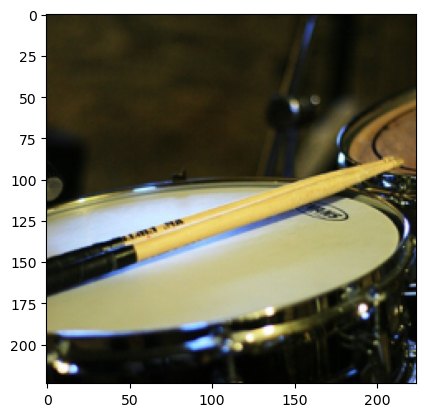

In [11]:
plt.imshow(denorm(x[0]))

drum 0.052993472665548325


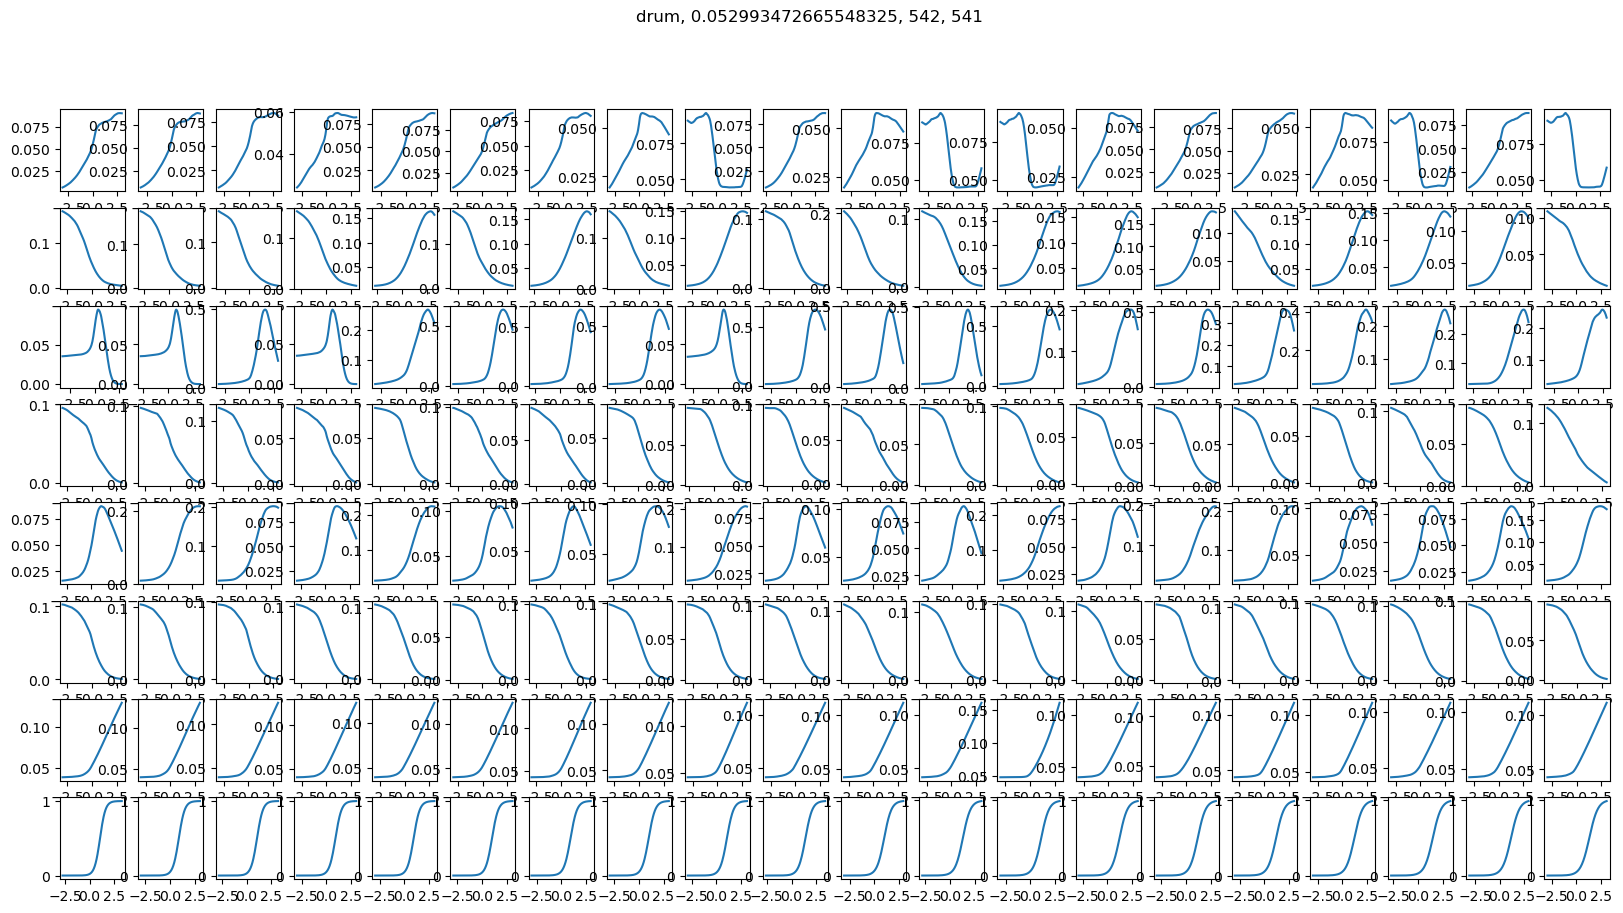

In [12]:
x, y = load_image(img_idx)
cls = val_ds.classes[y.item()]
print(wnid_words[cls], correct_ans_conf(model, x, y))
yhat_index=model(x).argmax().item()

fig=plt.figure(0, (20,10))
fig_count=1
for i, li in enumerate(LAYER_IDXS):
    name, layer = weighted_layers(model)[li]
    g = layer_grad(model,   layer,   x, y)
    
    picks = {}   # flat_idx -> list of (source, rank, gradval)
    vals, idxs = g.abs().topk(TOP_N)
    for rank, (v, fi) in enumerate(zip(vals.tolist(), idxs.tolist())):
        picks.setdefault(fi, []).append(('plain', rank, v))
    
    for j, (flat_idx, sources) in enumerate(picks.items()):
        # flat_idx=133 
        sources=[('plain', 0, 4.481142044067383)]
        
        coord = np.unravel_index(flat_idx, layer.weight.shape)
        vals, res, w0 = sweep_weight(model, layer, flat_idx, x, y, mode='conf')

        ax=fig.add_subplot(len(LAYER_IDXS), len(picks), fig_count)
        fig_count+=1
        ax.plot(vals, res)
        # plt.axis('off')
        # plt.title(f"layer {li} ({name})  w {flat_idx} {coord}  " f"img {img_idx} ({cls})")
    plt.suptitle(str(wnid_words[cls]) +', ' +str(correct_ans_conf(model, x, y))+', '+str(yhat_index)+', '+str(y.item()))


- Ok I like drum, it's unambiguous, easy to understand. 

In [23]:
# model

In [80]:
# wnid_words

In [20]:
img_idx=27083 
TOP_N = 256

In [21]:
x, y = load_image(img_idx)
cls = val_ds.classes[y.item()]
print(wnid_words[cls], correct_ans_conf(model, x, y))
yhat_index=model(x).argmax().item()

drum 0.052993472665548325


In [24]:
print(wnid_words[val_ds.classes[yhat_index]])

drumstick


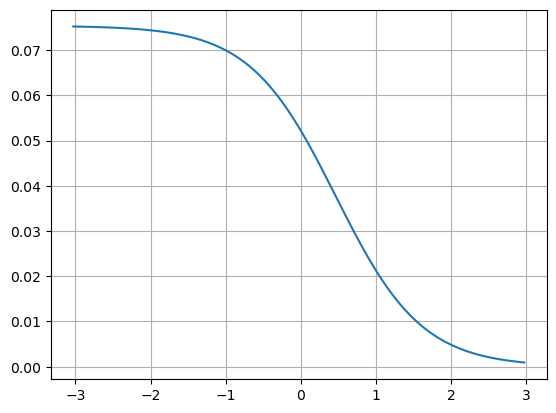

In [25]:
li=-1 #Fc layer brow
param_index=200

name, layer = weighted_layers(model)[li]
g = layer_grad(model, layer,   x, y)
vals, idxs = g.abs().topk(TOP_N)

flat_idx=idxs[param_index].item()
coord = np.unravel_index(flat_idx, layer.weight.shape)
vals, res, w0 = sweep_weight(model, layer, flat_idx, x, y, mode='conf')
plt.plot(vals, res); plt.grid(1)

In [26]:
coord

(np.int64(542), np.int64(138))

In [27]:
layer.weight.shape

torch.Size([1000, 256])

In [28]:
layer

Linear(in_features=256, out_features=1000, bias=True)

In [29]:
w = layer.weight.view(-1)
w0 = w[flat_idx].item()

In [30]:
w0 #Initial value. 

-0.029405327513813972

In [31]:
def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"total: {total:,}  ({total/1e6:.2f}M)   trainable: {trainable:,}")
    return total

count_params(model)

total: 1,447,976  (1.45M)   trainable: 1,447,976


1447976

In [32]:
correct_ans_conf(model, x, y)

0.052993472665548325

In [33]:
w[flat_idx]

tensor(-0.0294, device='cuda:0', grad_fn=<SelectBackward0>)

In [34]:
with torch.no_grad():
    w[flat_idx] = w0+0.1
    c=correct_ans_conf(model, x, y)
print(w[flat_idx].item(), c)

0.0705946758389473 0.050150126218795776


In [35]:
with torch.no_grad():
    w[flat_idx] = w0-0.1
    c=correct_ans_conf(model, x, y)
print(w[flat_idx].item(), c)

-0.12940533459186554 0.05564301088452339


In [36]:
with torch.no_grad():
    w[flat_idx] = w0 #Put back

## P28 
- More curves for the 8 layer model
- Ok I'm thinking here i should go ahead and pick a curve for each layer

drum 0.052993472665548325


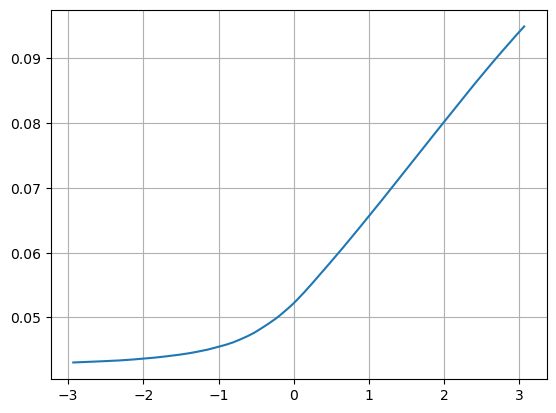

In [44]:
li=6
param_index=100

x, y = load_image(img_idx)
cls = val_ds.classes[y.item()]
print(wnid_words[cls], correct_ans_conf(model, x, y))
yhat_index=model(x).argmax().item()


name, layer = weighted_layers(model)[li]
g = layer_grad(model, layer,   x, y)
vals, idxs = g.abs().topk(TOP_N)

flat_idx=idxs[param_index].item()
coord = np.unravel_index(flat_idx, layer.weight.shape)
vals, res, w0 = sweep_weight(model, layer, flat_idx, x, y, mode='conf')
plt.plot(vals, res); plt.grid(1)

drum 0.052993472665548325


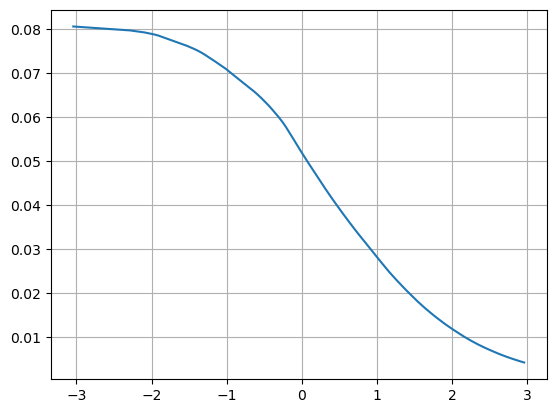

In [47]:
li=5
param_index=100

x, y = load_image(img_idx)
cls = val_ds.classes[y.item()]
print(wnid_words[cls], correct_ans_conf(model, x, y))
yhat_index=model(x).argmax().item()


name, layer = weighted_layers(model)[li]
g = layer_grad(model, layer,   x, y)
vals, idxs = g.abs().topk(TOP_N)

flat_idx=idxs[param_index].item()
coord = np.unravel_index(flat_idx, layer.weight.shape)
vals, res, w0 = sweep_weight(model, layer, flat_idx, x, y, mode='conf')
plt.plot(vals, res); plt.grid(1)

drum 0.052993472665548325


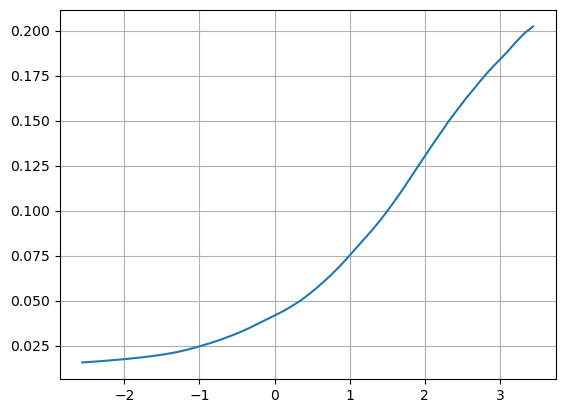

In [48]:
li=4
param_index=100

x, y = load_image(img_idx)
cls = val_ds.classes[y.item()]
print(wnid_words[cls], correct_ans_conf(model, x, y))
yhat_index=model(x).argmax().item()


name, layer = weighted_layers(model)[li]
g = layer_grad(model, layer,   x, y)
vals, idxs = g.abs().topk(TOP_N)

flat_idx=idxs[param_index].item()
coord = np.unravel_index(flat_idx, layer.weight.shape)
vals, res, w0 = sweep_weight(model, layer, flat_idx, x, y, mode='conf')
plt.plot(vals, res); plt.grid(1)

drum 0.052993472665548325


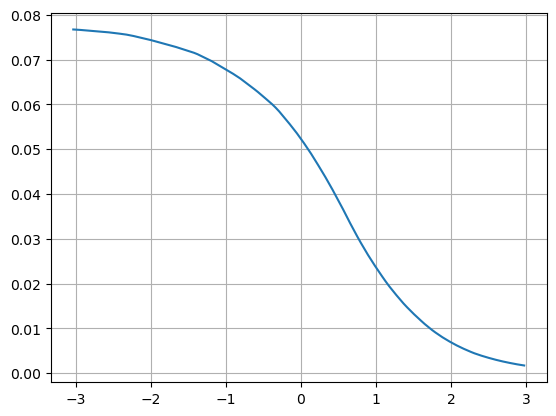

In [50]:
li=3
param_index=100

x, y = load_image(img_idx)
cls = val_ds.classes[y.item()]
print(wnid_words[cls], correct_ans_conf(model, x, y))
yhat_index=model(x).argmax().item()


name, layer = weighted_layers(model)[li]
g = layer_grad(model, layer,   x, y)
vals, idxs = g.abs().topk(TOP_N)

flat_idx=idxs[param_index].item()
coord = np.unravel_index(flat_idx, layer.weight.shape)
vals, res, w0 = sweep_weight(model, layer, flat_idx, x, y, mode='conf')
plt.plot(vals, res); plt.grid(1)

drum 0.052993472665548325


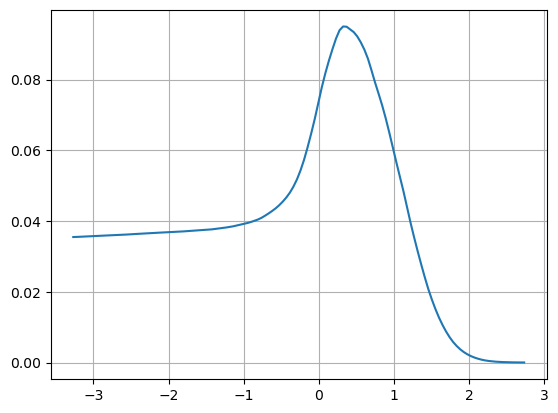

In [61]:
li=2
param_index=0

x, y = load_image(img_idx)
cls = val_ds.classes[y.item()]
print(wnid_words[cls], correct_ans_conf(model, x, y))
yhat_index=model(x).argmax().item()


name, layer = weighted_layers(model)[li]
g = layer_grad(model, layer,   x, y)
vals, idxs = g.abs().topk(TOP_N)

flat_idx=idxs[param_index].item()
coord = np.unravel_index(flat_idx, layer.weight.shape)
vals, res, w0 = sweep_weight(model, layer, flat_idx, x, y, mode='conf')
plt.plot(vals, res); plt.grid(1)

drum 0.052993472665548325


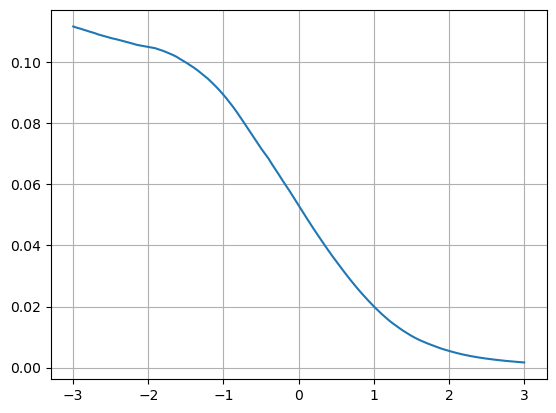

In [87]:
li=1
param_index=11

x, y = load_image(img_idx)
cls = val_ds.classes[y.item()]
print(wnid_words[cls], correct_ans_conf(model, x, y))
yhat_index=model(x).argmax().item()


name, layer = weighted_layers(model)[li]
g = layer_grad(model, layer,   x, y)
vals, idxs = g.abs().topk(TOP_N)

flat_idx=idxs[param_index].item()
coord = np.unravel_index(flat_idx, layer.weight.shape)
vals, res, w0 = sweep_weight(model, layer, flat_idx, x, y, mode='conf')
plt.plot(vals, res); plt.grid(1)

drum 0.052993472665548325


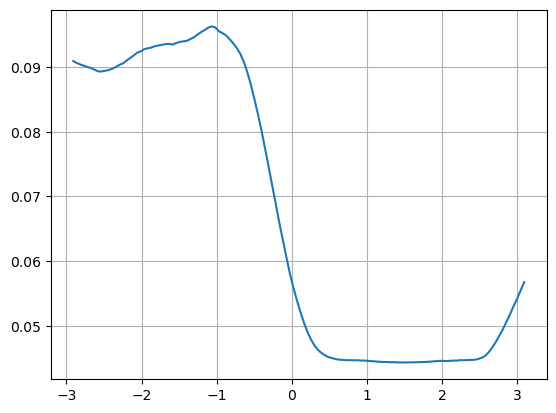

In [96]:
li=0
param_index=8

x, y = load_image(img_idx)
cls = val_ds.classes[y.item()]
print(wnid_words[cls], correct_ans_conf(model, x, y))
yhat_index=model(x).argmax().item()


name, layer = weighted_layers(model)[li]
g = layer_grad(model, layer,   x, y)
vals, idxs = g.abs().topk(TOP_N)

flat_idx=idxs[param_index].item()
coord = np.unravel_index(flat_idx, layer.weight.shape)
vals, res, w0 = sweep_weight(model, layer, flat_idx, x, y, mode='conf')
plt.plot(vals, res); plt.grid(1)

Ok great, so we have nice representative curves for each layer. 

## P30 
- Ok so just adding CE loss on top of these plots, could do this manim or elsewhere.

drum 0.052993472665548325


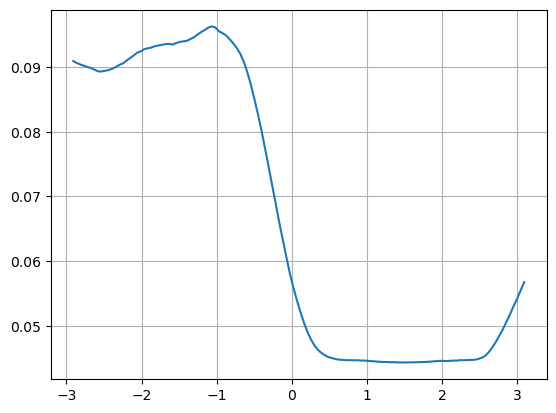

In [103]:
li=0
param_index=8

x, y = load_image(img_idx)
cls = val_ds.classes[y.item()]
print(wnid_words[cls], correct_ans_conf(model, x, y))
yhat_index=model(x).argmax().item()


name, layer = weighted_layers(model)[li]
g = layer_grad(model, layer,   x, y)
vals, idxs = g.abs().topk(TOP_N)

flat_idx=idxs[param_index].item()
coord = np.unravel_index(flat_idx, layer.weight.shape)
vals, res, w0 = sweep_weight(model, layer, flat_idx, x, y, mode='conf')
plt.plot(vals, res); plt.grid(1)

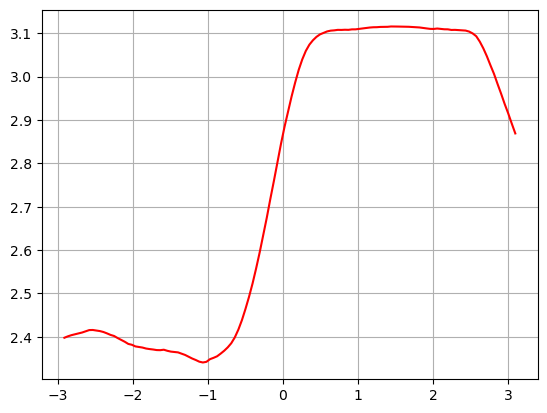

In [106]:
plt.plot(vals, -np.log(res), c='r'); plt.grid(1)

- Ok since probs are low, will probably need to use different scales for each.
- Are we worried about the drumstick/drum confusion?
- Idk it's probably fine?
- Is it weird to use an alread trained model here? Again probably ok?

---

In [ ]:


# li=-1
plt.clf()
fig=plt.figure(0, (20,10))
fig_count=1
for i, li in enumerate(LAYER_IDXS):
    name, layer = weighted_layers(model)[li]
    g = layer_grad(model,   layer,   x, y)
    
    picks = {}   # flat_idx -> list of (source, rank, gradval)
    vals, idxs = g.abs().topk(TOP_N)
    for rank, (v, fi) in enumerate(zip(vals.tolist(), idxs.tolist())):
        picks.setdefault(fi, []).append(('plain', rank, v))
    
    for j, (flat_idx, sources) in enumerate(picks.items()):
        # flat_idx=133 
        sources=[('plain', 0, 4.481142044067383)]
        
        coord = np.unravel_index(flat_idx, layer.weight.shape)
        vals, res, w0 = sweep_weight(model, layer, flat_idx, x, y, mode='conf')

        ax=fig.add_subplot(len(LAYER_IDXS), len(picks), fig_count)
        fig_count+=1
        ax.plot(vals, res)
        # plt.axis('off')
        # plt.title(f"layer {li} ({name})  w {flat_idx} {coord}  " f"img {img_idx} ({cls})")
    plt.suptitle(str(wnid_words[cls]) +', ' +str(correct_ans_conf(model, x, y))+', '+str(yhat_index)+', '+str(y.item()))
plt.savefig(save_dir/(str(img_idx)+'.png'))

---

In [107]:
wnid_words[cls]

'ice bear'

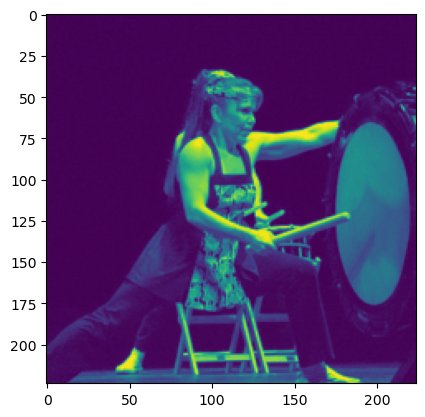

In [95]:
plt.imshow(x[0, 0].detach().cpu())

Text(0.5, 1.0, 'layer -1 (fc)  w 133 (np.int64(0), np.int64(133))  img 1000 (n01601694)')

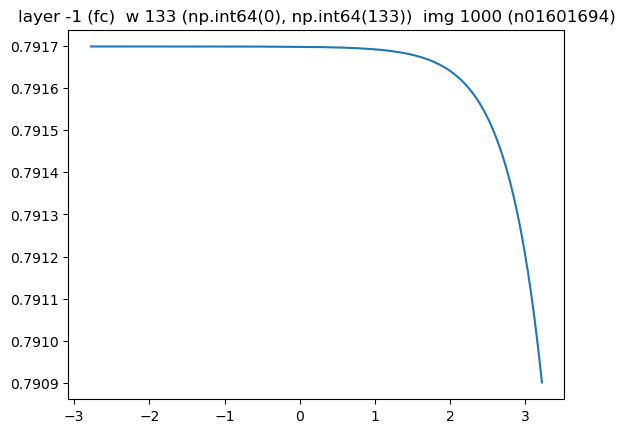

In [85]:
img_idx=1000
# for i, img_idx in enumerate(tqdm(img_idxs, desc="images")_:
x, y = load_image(img_idx)
cls = val_ds.classes[y.item()]

li=-1
# for li in LAYER_IDXS:
name, layer = weighted_layers(model)[li]
g = layer_grad(model,   layer,   x, y)

picks = {}   # flat_idx -> list of (source, rank, gradval)
vals, idxs = g.abs().topk(TOP_N)
for rank, (v, fi) in enumerate(zip(vals.tolist(), idxs.tolist())):
    picks.setdefault(fi, []).append(('plain', rank, v))

out_dir = root / f"layer{li:03d}_{name.replace('.', '-')}"
out_dir.mkdir(parents=True, exist_ok=True)

# for flat_idx, sources in picks.items():
flat_idx=133 
sources=[('plain', 0, 4.481142044067383)]

coord = np.unravel_index(flat_idx, layer.weight.shape)
vals, res, w0 = sweep_weight(model, layer, flat_idx, x, y, mode='conf')

plt.plot(vals, res)
plt.title(f"layer {li} ({name})  w {flat_idx} {coord}  " f"img {img_idx} ({cls})")

In [68]:
x.shape

torch.Size([1, 3, 224, 224])

In [69]:
y.shape

torch.Size([1])

In [70]:
correct_ans_conf(model, x, y)

0.7916975021362305

In [71]:
batch_loss_fp32(model, x, y)

0.23357592523097992

In [74]:
-np.log(0.791697)

np.float64(0.2335765361260626)

In [59]:
# with torch.no_grad():
#     yhat=torch.nn.Softmax()(model(x))[0, y.item()]

In [60]:
yhat

tensor(0.7917, device='cuda:0')

In [11]:
# ---- run: outer loop over images, inner over layers, sweep top-N in both models ----
root = Path(f"/home/stephen/Stephencwelch Dropbox/welch_labs/resnet/hackin/aug_21/grad_ranked_sweeps/d8_imgseed{IMG_SEED}_top{TOP_N}_span{SPAN}")

for img_idx in tqdm(img_idxs, desc="images"):
    x, y = load_image(img_idx)
    cls = val_ds.classes[y.item()]

    for li in LAYER_IDXS:
        name, layer = weighted_layers(model)[li]
        g = layer_grad(model_skip,   layer,   x, y)

        picks = {}   # flat_idx -> list of (source, rank, gradval)
        vals, idxs = g.abs().topk(TOP_N)
        for rank, (v, fi) in enumerate(zip(vals.tolist(), idxs.tolist())):
            picks.setdefault(fi, []).append(('plain', rank, v))
                
        out_dir = root / f"layer{li:03d}_{name.replace('.', '-')}"
        out_dir.mkdir(parents=True, exist_ok=True)

        for flat_idx, sources in picks.items():
            coord = np.unravel_index(flat_idx, layer.weight.shape)
            v_p, l_p, w0_p = sweep_weight(model, layer, flat_idx, x, y)

            src_str = ",".join(f"{s}#{r}" for s, r, _ in sources)
            fig, axes = plt.subplots(1, 2, figsize=(10, 4))
            for ax, v, l, w0, title, c, g in [
                (axes[0], v_p, l_p, w0_p, "plainnet (no skip)", "tab:red",  g_p),
                (axes[1], v_r, l_r, w0_r, "resnet (skip)",      "tab:blue", g_r),
            ]:
                ax.plot(v, l, color=c, lw=1.5)
                ax.axvline(w0, ls="--", lw=1, color="gray", label=f"w0 = {w0:.3f}")
                ax.set_xlabel("weight value")
                ax.set_ylabel(r"$\Delta$ loss" if PLOT_DELTA else "loss")
                ax.set_title(f"{title}   |g| = {g[flat_idx].abs().item():.2e}")
                ax.legend(fontsize=8)
            fig.suptitle(f"d74 fp32  layer {li} ({name})  w {flat_idx} {coord}  "
                         f"img {img_idx} ({cls})  ranked by: {src_str}")
            fig.tight_layout()
            best_rank = min(r for _, r, _ in sources)
            fig.savefig(out_dir / f"img{img_idx:06d}_rank{best_rank:02d}_w{flat_idx:08d}.png",
                        dpi=150)
            plt.close(fig)

print(f"done -> {root}/")

images:   0%|                                                 | 0/512 [00:00<?, ?it/s]


NameError: name 'weighted_layers' is not defined